Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


  if event.key is 'enter':



Moviepy - Building video graf_shift_kerja_with_audio.mp4.
MoviePy - Writing audio in graf_shift_kerja_with_audioTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video graf_shift_kerja_with_audio.mp4



Moviepy - Done !
Moviepy - video ready graf_shift_kerja_with_audio.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

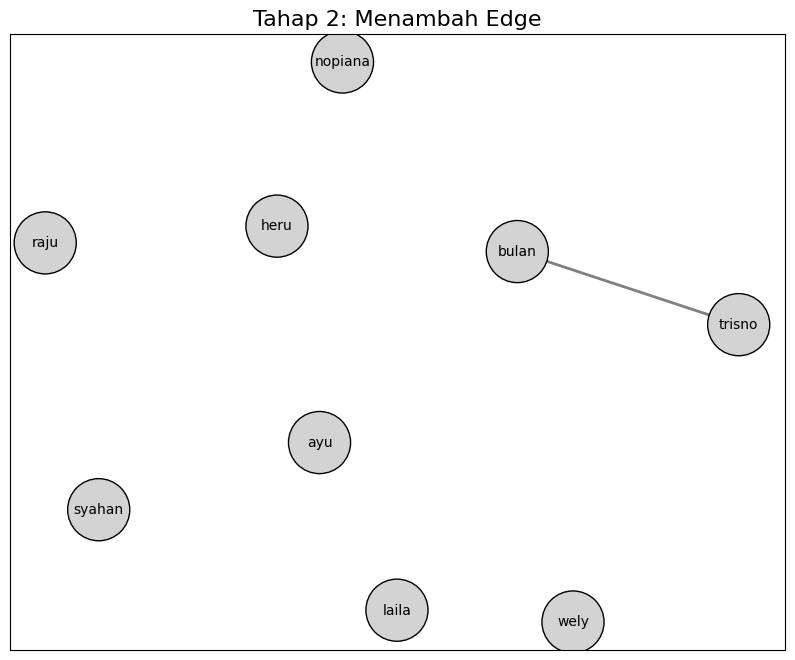

In [ ]:
# Instalasi library yang dibutuhkan
!apt-get install -y ffmpeg
!pip install gtts moviepy

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from gtts import gTTS
from moviepy.editor import VideoFileClip, AudioFileClip

# Data jadwal shift
shifts = {
    "bulan": ["pg", "siang", "siang", "pg", "siang", "siang", "pg"],
    "ayu": ["siang", "pg", "off", "siang", "pg", "pg", "siang"],
    "trisno": ["siang", "off", "pg", "pg", "pg", "pg", "pg"],
    "syahan": ["pg", "pg", "siang", "siang", "siang", "siang", "siang"],
    "raju": ["pg", "siang", "off", "siang", "siang", "siang", "siang"],
    "heru": ["siang", "siang", "siang", "pg", "pg", "pg", "pg"],
    "nopiana": ["siang", "siang", "siang", "siang", "off", "pg", "pg"],
    "wely": ["pg", "pg", "pg", "off", "siang", "siang", "siang"],
    "laila": ["off", "pg", "pg", "pg", "pg", "pg", "pg"]
}

# Membuat graf
G = nx.Graph()

# Menambahkan simpul dan edge berdasarkan shift mingguan
for employee, schedule in shifts.items():
    for other_employee, other_schedule in shifts.items():
        if employee != other_employee:
            # Jika terdapat minimal 1 shift yang sama selama seminggu
            if any(s == o and s != "off" for s, o in zip(schedule, other_schedule)):
                G.add_edge(employee, other_employee)

# Pewarnaan manual untuk simpul
color_map = {
    "bulan": "deepskyblue",  # Ocean Blue
    "ayu": "forestgreen",    # Forest Green
    "trisno": "lightpink",   # Soft Blush
    "syahan": "magenta",     # Deep Magenta
    "raju": "gold",          # Fire Yellow
    "heru": "deepskyblue",
    "nopiana": "forestgreen",
    "wely": "lightpink",
    "laila": "magenta",
}

# Posisi node untuk graf
pos = nx.spring_layout(G, seed=42)

# Tahap 1: Semua simpul tanpa warna (default putih)
frames = []

# Tahap 2: Visualisasi koneksi satu per satu
edges = list(G.edges)
nodes = list(G.nodes)
for i in range(len(edges)):
    frames.append((edges[:i+1], ["lightgray" for _ in nodes]))  # Default warna node terang

# Tahap 3: Pewarnaan simpul
for i in range(len(nodes)):
    current_colors = [color_map[nodes[j]] if j <= i else "lightgray" for j in range(len(nodes))]
    frames.append((edges, current_colors))

# Fungsi pembaruan untuk setiap frame
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame):
    ax.clear()
    edges_to_draw, node_colors = frames[frame]

    # Gambar edges dan simpul
    nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, edge_color="gray", width=2)
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=node_colors, edgecolors="black")
    nx.draw_networkx_labels(G, pos, font_size=10, font_color="black")

    # Tambahkan teks judul
    if frame < len(edges):
        plt.title("Tahap 2: Menambah Edge", fontsize=16)
    else:
        plt.title("Tahap 3: Pewarnaan Simpul", fontsize=16)

# Membuat animasi
ani = FuncAnimation(fig, update, frames=len(frames), interval=1000, repeat=False)

# Simpan video animasi
video_path = "graf_shift_kerja_with_animation.mp4"
ani.save(video_path, writer=animation.FFMpegWriter(fps=1))

# Derajat setiap simpul
degree_info = "Derajat Simpul:\n"
for node in G.nodes:
    degree_info += f"{node}: {G.degree[node]}\n"

# Node yang bisa change shift
change_shift_info = "\nNode yang Bisa Change Shift:\n"
for node in G.nodes:
    can_change = [n for n in G.neighbors(node)]
    change_shift_info += f"{node} bisa change shift dengan: {', '.join(can_change)}\n"

# Gabungkan semua informasi menjadi narasi
narration_text = degree_info + change_shift_info

# Generate audio penjelasan menggunakan gTTS
audio_path = "narration.mp3"
tts = gTTS(narration_text, lang="id")
tts.save(audio_path)

# Gabungkan audio dengan video menggunakan moviepy
video = VideoFileClip(video_path)
audio = AudioFileClip(audio_path)
final_video = video.set_audio(audio)
final_video_path = "graf_shift_kerja_with_audio.mp4"
final_video.write_videofile(final_video_path, codec="libx264", audio_codec="aac")

# Unduh video hasil akhir
from google.colab import files
files.download(final_video_path)
